In [1]:
import pandas as pd
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
# seaborn is of use for visualizing.
import seaborn as sns

# load train, test, and submission sample dataset.
train_csv = pd.read_csv('../input/petfinder-pawpularity-score/train.csv')
test_csv = pd.read_csv('../input/petfinder-pawpularity-score/test.csv')
submission = pd.read_csv('../input/petfinder-pawpularity-score/sample_submission.csv')


2026-01-07 04:11:00.729623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767759060.743189      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767759060.747575      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 04:11:00.766570: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
train_csv


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8915,ee97d86d26506239666d3679ff4a73aa,0,0,1,1,0,0,0,0,0,0,0,1,31
8916,7cf13d655a8d0d6a1d636c3920d49e86,0,0,1,1,0,0,0,0,0,0,0,0,33
8917,547e443edbf94b3646ff110324846bae,0,1,1,0,0,0,1,0,0,0,0,0,27
8918,fe2b587f649b9780900246c4b174a231,0,1,1,1,0,0,1,0,0,0,0,0,27


In [3]:
train_csv.isnull().sum()


Id               0
Subject Focus    0
Eyes             0
Face             0
Near             0
Action           0
Accessory        0
Group            0
Collage          0
Human            0
Occlusion        0
Info             0
Blur             0
Pawpularity      0
dtype: int64

In [4]:
train_csv.drop_duplicates()


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8915,ee97d86d26506239666d3679ff4a73aa,0,0,1,1,0,0,0,0,0,0,0,1,31
8916,7cf13d655a8d0d6a1d636c3920d49e86,0,0,1,1,0,0,0,0,0,0,0,0,33
8917,547e443edbf94b3646ff110324846bae,0,1,1,0,0,0,1,0,0,0,0,0,27
8918,fe2b587f649b9780900246c4b174a231,0,1,1,1,0,0,1,0,0,0,0,0,27


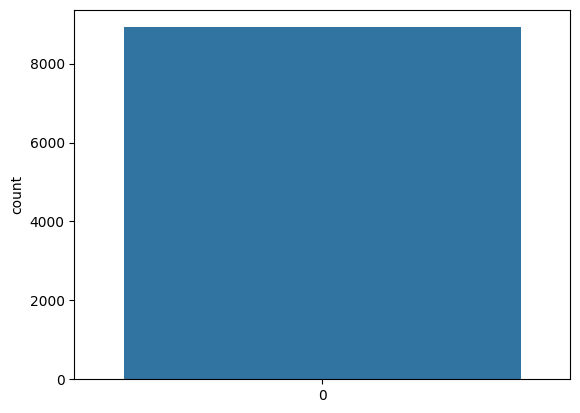

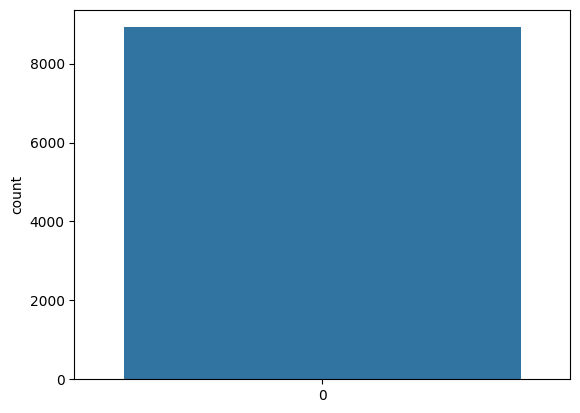

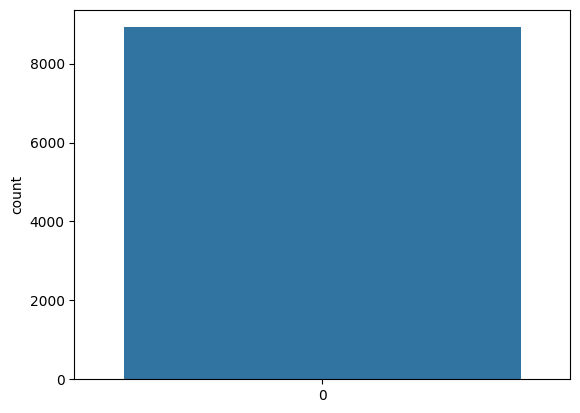

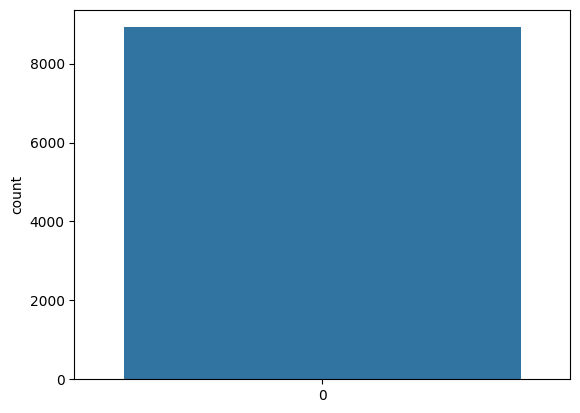

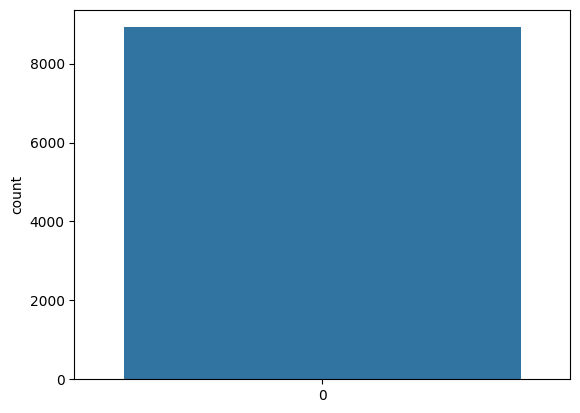

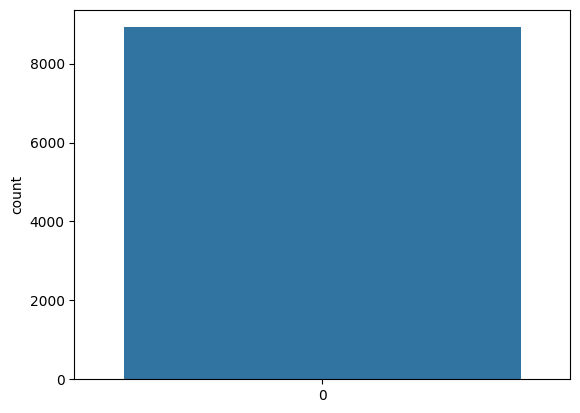

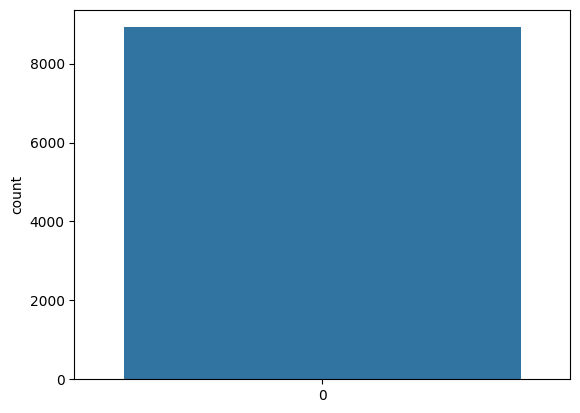

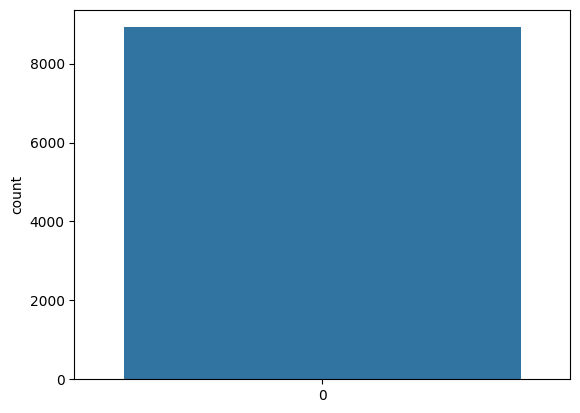

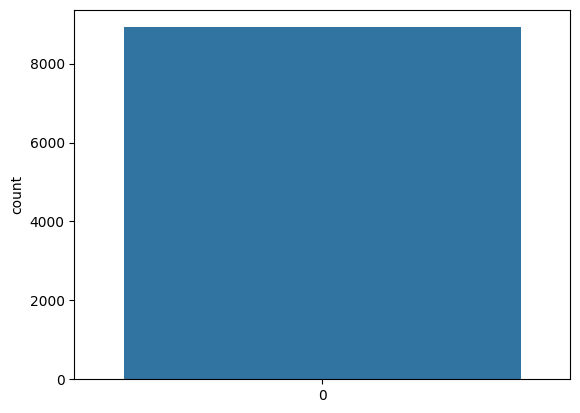

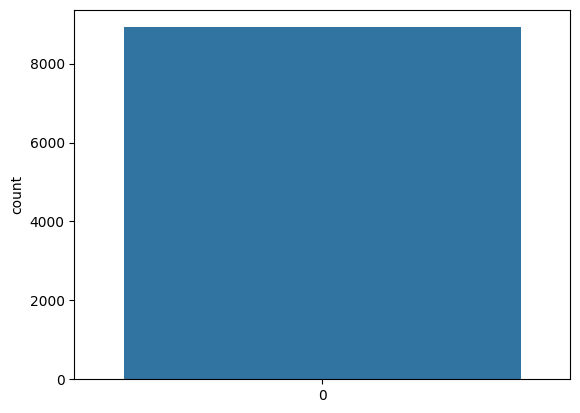

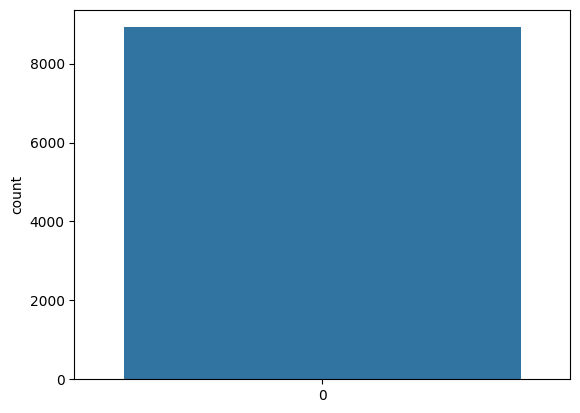

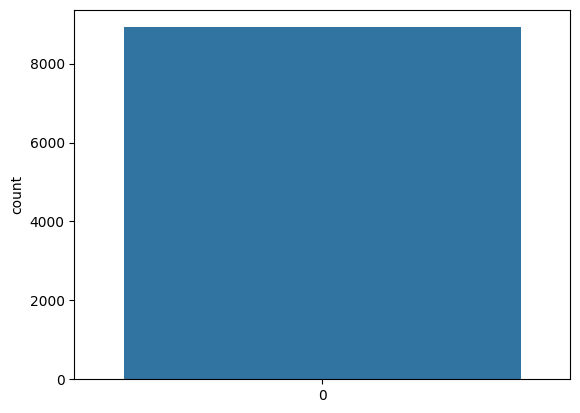

In [5]:
for i in train_csv.drop(['Id','Pawpularity'],axis=1):
    sns.countplot(train_csv[i])
    plt.show()


/tmp/ipykernel_11/4105878513.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_csv['Pawpularity'])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Pawpularity', ylabel='Density'>

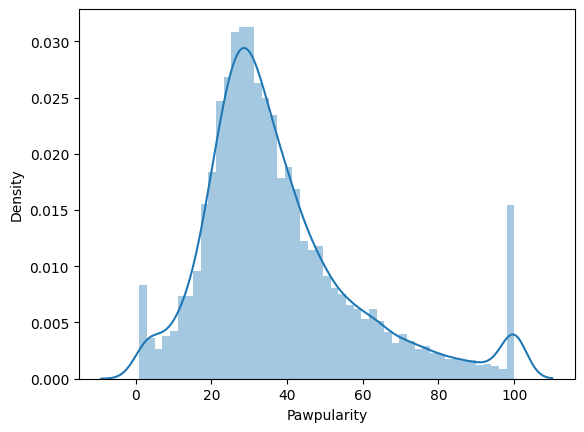

In [6]:
sns.distplot(train_csv['Pawpularity'])


In [7]:
test_csv


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur
0,ee51b99832f1ba868f646df93d2b6b81,0,1,1,1,0,0,0,0,0,0,0,0
1,caddfb3f8bff9c4b95dbe022018eea21,0,0,1,1,0,1,1,0,0,0,0,0
2,582eeabd4a448a53ebb79995888a4b0b,0,1,1,0,0,0,0,0,0,0,0,0
3,afc1ad7f0c5eea880759d09e77f7deee,0,1,1,1,0,0,0,0,0,0,0,0
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,0,1,1,0,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,0,1,1,1,0,0,1,0,0,0,0,0
988,8064261ce5f7197fdc849641b3192eef,0,1,1,1,0,0,0,0,0,1,0,0
989,a5ff4923e393fa08e67da31c7eb4edd5,0,1,1,1,0,0,0,0,0,0,0,0
990,fa6a53f962225c17b22392748f91f9ac,0,1,1,1,0,0,0,0,0,0,0,0


In [8]:
test_csv.isnull().sum()


Id               0
Subject Focus    0
Eyes             0
Face             0
Near             0
Action           0
Accessory        0
Group            0
Collage          0
Human            0
Occlusion        0
Info             0
Blur             0
dtype: int64

In [9]:
submission


,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,64.06
1,caddfb3f8bff9c4b95dbe022018eea21,27.71
2,582eeabd4a448a53ebb79995888a4b0b,5.06
3,afc1ad7f0c5eea880759d09e77f7deee,2.64
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,81.51
...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,8.30
988,8064261ce5f7197fdc849641b3192eef,68.64
989,a5ff4923e393fa08e67da31c7eb4edd5,80.13
990,fa6a53f962225c17b22392748f91f9ac,64.54


In [10]:
# Set the path for loading image dataset.
os.chdir('../input/petfinder-pawpularity-score/train')

# We can find the size of each image data from this procedure
size_data = pd.DataFrame()
for file in os.listdir():
    imgg = cv2.imread(file)
    w,h,c = imgg.shape
    size_data=size_data.append([[w,h,c,imgg.size/3]])
size_data


AttributeError: 'DataFrame' object has no attribute 'append'

In [11]:
size_data[size_data[3] == size_data[3].min()]


KeyError: 3

In [12]:
size_data[3].value_counts()


KeyError: 3

In [13]:
size_data[size_data[3] == 691200]


KeyError: 3

In [14]:
train_img = []
for i in os.listdir():
    file = cv2.imread(i)
    file=cv2.resize(file,(64,64), interpolation=cv2.INTER_AREA)
    train_img.append(file/255)
train_img[:5]


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [15]:
train_img_name = []
for i in os.listdir():
    train_img_name.append(i)
train_img_name[:5]


['e449bbacd2930d6f6ab4589182a09185.jpg',
 'cfe66786a9c53db0e6936209291cc67d.jpg',
 '6cf284fbd74fb0b916f279b8c9486c44.jpg',
 '916ce20c02cd4ef9225d7dbabde68f1c.jpg',
 'c3214f7072e168d0a2f9ee6b4ddcd3c1.jpg']

In [16]:
for name in train_img_name:
    if name[-4:] != '.jpg':
        print(name)


train


In [17]:
train_csv_data = pd.DataFrame()
for img, name in zip(train_img, train_img_name):
    name=name[:-4]
    location = train_csv[train_csv['Id'] == name].index[0]
    train_csv_data= train_csv_data.append([train_csv.loc[location]])
train_csv_data


AttributeError: 'DataFrame' object has no attribute 'append'

In [18]:
train_csv_data=train_csv_data.reset_index().drop(['index'],axis=1)
train_csv_data


""


In [19]:
image_1 = cv2.imread('./'+train_csv_data['Id'][0]+'.jpg')
plt.imshow(image_1)


KeyError: 'Id'

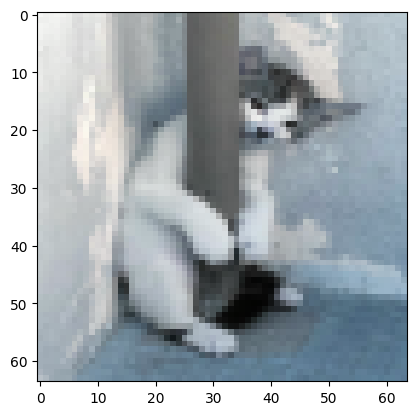

In [20]:
plt.imshow(train_img[0])


In [21]:
image_2 = cv2.imread('./'+train_csv_data['Id'][1]+'.jpg')
plt.imshow(image_2)


KeyError: 'Id'

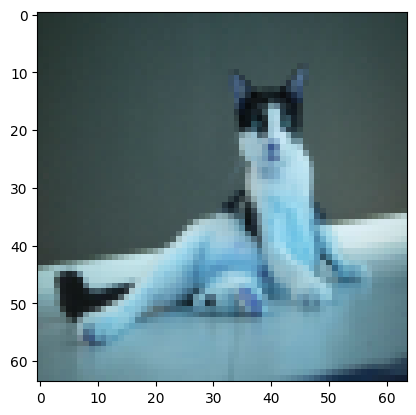

In [22]:
plt.imshow(train_img[1])


In [23]:
os.chdir('../test')

for i in os.listdir():
    file = cv2.imread(i)
    print(file.shape)


(640, 480, 3)
(960, 542, 3)
(321, 219, 3)
(959, 540, 3)
(960, 720, 3)
(960, 656, 3)
(960, 720, 3)
(959, 540, 3)
(960, 720, 3)
(960, 720, 3)
(727, 555, 3)
(592, 501, 3)
(1280, 1280, 3)
(905, 1061, 3)
(959, 540, 3)
(960, 720, 3)
(960, 467, 3)
(1280, 1280, 3)
(960, 720, 3)
(960, 720, 3)
(667, 566, 3)
(720, 960, 3)
(720, 405, 3)
(720, 1280, 3)
(960, 782, 3)
(960, 513, 3)
(483, 671, 3)
(720, 960, 3)
(826, 659, 3)
(960, 1280, 3)
(960, 720, 3)
(587, 1280, 3)
(635, 960, 3)
(960, 720, 3)
(960, 528, 3)
(960, 1280, 3)
(650, 893, 3)
(318, 285, 3)
(720, 1280, 3)
(960, 720, 3)
(960, 720, 3)
(810, 1080, 3)
(960, 720, 3)
(960, 720, 3)
(720, 1280, 3)
(960, 540, 3)
(960, 540, 3)
(960, 719, 3)
(960, 560, 3)
(960, 720, 3)
(1202, 1279, 3)
(733, 535, 3)
(960, 720, 3)
(847, 1279, 3)
(960, 905, 3)
(720, 405, 3)
(960, 720, 3)
(720, 405, 3)
(1280, 1280, 3)
(960, 1280, 3)
(720, 405, 3)
(960, 640, 3)
(960, 720, 3)
(960, 699, 3)
(960, 960, 3)
(962, 1280, 3)
(1280, 1280, 3)
(960, 720, 3)
(656, 492, 3)
(943, 683, 3)

AttributeError: 'NoneType' object has no attribute 'shape'

In [24]:
test_img = []
for i in os.listdir():
    file = cv2.imread(i)
    file=cv2.resize(file,(64,64), interpolation=cv2.INTER_AREA)
    test_img.append(file/255)
test_img[:5]


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [25]:
test_img_name = []
for i in os.listdir():
    test_img_name.append(i)
test_img_name[:5]


['a5c4de4c29e2097889f0d4cbd566625c.jpg',
 '2e5cda2c4cf0530423e8181b7f8c67bc.jpg',
 '98df091086f51b9ea2b26fcccefe11bb.jpg',
 'db56a293c25086ba38f801f674c45689.jpg',
 '7f3583a21d03cbc6b705f71f57a1a8d1.jpg']

In [26]:
test_csv_data = pd.DataFrame()
for img, name in zip(test_img, test_img_name):
    name=name[:-4]
    location = test_csv[test_csv['Id'] == name].index[0]
    test_csv_data= test_csv_data.append([test_csv.loc[location]])
test_csv_data=test_csv_data.reset_index().drop(['index'],axis=1)
test_csv_data


AttributeError: 'DataFrame' object has no attribute 'append'

In [27]:
test_1 = cv2.imread('./'+test_csv_data['Id'][0]+'.jpg')
plt.imshow(test_1)


KeyError: 'Id'

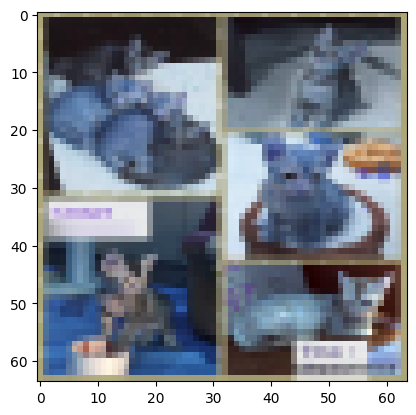

In [28]:
plt.imshow(test_img[0])


In [29]:
train_csv_x = train_csv_data.drop(['Id','Pawpularity'],axis=1)
train_y = train_csv_data['Pawpularity']

test_csv_x = test_csv_data.drop(['Id'],axis=1)


KeyError: "['Id', 'Pawpularity'] not found in axis"

In [30]:
# ##################### CSV FILE INPUT & IMG FILE INPUT LAYER ###########################
# csv_input = tf.keras.Input(shape = train_csv_x.shape[1:], name = 'CSV_Input')        ##
# img_input = tf.keras.Input(shape = np.array(train_img).shape[1:], name = 'IMG_Input')##
# #######################################################################################
#                                         ##
#                                         ##
#                                         ##
# ##################### CSV FILE HIDDEN LAYER STRUCTURE  ######################################
# csv_hidden1 = tf.keras.layers.Dense(200, activation='relu', name='CSV_Hidden1')(csv_input)   ##
# csv_hidden2 = tf.keras.layers.Dense(200, activation='relu', name='CSV_Hidden2')(csv_hidden1)##
# csv_hidden3 = tf.keras.layers.Dense(200, activation='relu', name='CSV_Hidden3')(csv_hidden2)##
# csv_dropout = tf.keras.layers.Dropout(0.5, name ='CSV_Dropout')(csv_hidden3)               ##
# csv_hidden4 = tf.keras.layers.Dense(200, activation='relu', name='CSV_Hidden4')(csv_dropout)##
# csv_hidden5 = tf.keras.layers.Dense(200, activation='relu', name='CSV_Hidden5')(csv_hidden4)##
# #############################################################################################
#                                          #
#                                          #
#                                          #
# ##################### IMG FILE CONVOLUTIONAL LAYER STRUCTURE  ######################################
# img_conv1 = tf.keras.layers.Conv2D(filters = 120, kernel_size = 5, strides= 1, padding = 'same',   ##
#                                    activation = 'relu', name='IMG_Conv1')(img_input)              ##
# img_pool1 = tf.keras.layers.MaxPool2D(3, name = 'IMG_Pool1')(img_conv1)                           ##
# img_conv2 = tf.keras.layers.Conv2D(filters = 120, kernel_size = 4, strides= 1, padding = 'same',  ##
#                                    activation = 'relu', name='IMG_Conv2')(img_pool1)              ##
# img_conv3 = tf.keras.layers.Conv2D(filters = 120, kernel_size = 4, strides =1, padding = 'same',  ##
#                                    activation = 'relu', name='IMG_Conv3')(img_conv2)              ##
# img_pool2 = tf.keras.layers.MaxPool2D(3, name = 'IMG_Pool2')(img_conv3)                           ##
# img_conv4 = tf.keras.layers.Conv2D(filters = 120, kernel_size = 3, strides =1, padding = 'same',  ##
#                                    activation = 'relu', name='IMG_Conv4')(img_pool2)              ##
# img_pool3 = tf.keras.layers.MaxPool2D(3, name = 'IMG_Pool3')(img_conv4)                           ##
# img_conv5 = tf.keras.layers.Conv2D(filters = 120, kernel_size = 3, strides =1, padding = 'same',  ##
#                                    activation = 'relu', name='IMG_Conv5')(img_pool3)              ##
# img_conv6 = tf.keras.layers.Conv2D(filters = 120, kernel_size = 3, strides =1, padding = 'same',  ##
#                                    activation = 'relu', name='IMG_Conv6')(img_conv5)              ##
# img_pool4 = tf.keras.layers.MaxPool2D(2, name = 'IMG_Pool4')(img_conv6)                           ##
# img_flatten = tf.keras.layers.Flatten(name = 'IMG_Flatten')(img_pool4)                            ##
# img_dense1 = tf.keras.layers.Dense(300, activation = 'relu', name='IMG_Dense1')(img_flatten)     ##
# img_dropout1 = tf.keras.layers.Dropout(0.5, name='IMG_Dropout1')(img_dense1)                      ##
# img_dense2 = tf.keras.layers.Dense(300, activation = 'relu', name='IMG_Dense2')(img_dropout1)    ##
# img_dropout2 = tf.keras.layers.Dropout(0.5, name='IMG_Dropout2')(img_dense2)                      ##
# ####################################################################################################
#                                         ##
#                                         ##
#                                         ##
# ##################### CSV FILE INPUT & IMG FILE OUTPUT LAYER ############
# csv_output = tf.keras.layers.Dense(1, name = 'CSV_Output')(csv_hidden5)##
# img_output = tf.keras.layers.Dense(1,name = 'IMG_Output')(img_dropout2)##
# #########################################################################
#                                         ##
#                                         ##
#                                         ##
# ############################################# MODEL SETTING  ####################################################
# model = tf.keras.Model(inputs=[csv_input, img_input], outputs=[csv_output, img_output], name='Pythonash_model')##
# #################################################################################################################


In [31]:
csv_input = tf.keras.Input(shape = train_csv_x.shape[1:], name = 'CSV_Input')
img_input = tf.keras.Input(shape = np.array(train_img).shape[1:], name = 'IMG_Input')

csv_hidden1 = tf.keras.layers.Dense(200, activation='elu', kernel_initializer = 'he_normal', name='CSV_Hidden1')(csv_input)
csv_hidden2 = tf.keras.layers.Dense(200, activation='elu', kernel_initializer = 'he_normal', name='CSV_Hidden2')(csv_hidden1)
csv_hidden3 = tf.keras.layers.Dense(200, activation='elu', kernel_initializer = 'he_normal', name='CSV_Hidden3')(csv_hidden2)
csv_hidden4 = tf.keras.layers.Dense(200, activation='elu', kernel_initializer = 'he_normal', name='CSV_Hidden4')(csv_hidden3)
csv_hidden5 = tf.keras.layers.Dense(200, activation='elu', kernel_initializer = 'he_normal', name='CSV_Hidden5')(csv_hidden4)
csv_hidden6 = tf.keras.layers.Dense(200, activation='elu', kernel_initializer = 'he_normal', name='CSV_Hidden6')(csv_hidden5)
csv_dropout = tf.keras.layers.Dropout(0.5, name ='CSV_Dropout')(csv_hidden6)

img_conv1 = tf.keras.layers.Conv2D(120, 4, padding = 'same', activation = 'elu', kernel_initializer = 'he_normal',name='IMG_Conv1')(img_input)
img_conv2 = tf.keras.layers.Conv2D(120, 4, padding = 'same', activation = 'elu', kernel_initializer = 'he_normal',name='IMG_Conv2')(img_conv1)
img_pooling1 = tf.keras.layers.MaxPooling2D(4, name= 'IMG_Max1')(img_conv2)

img_conv3 = tf.keras.layers.Conv2D(120, 4, padding = 'same', activation = 'elu', kernel_initializer = 'he_normal',name='IMG_Conv3')(img_pooling1)
img_conv4 = tf.keras.layers.Conv2D(120, 4, padding = 'same', activation = 'elu', kernel_initializer = 'he_normal',name='IMG_Conv4')(img_conv3)
img_pooling2 = tf.keras.layers.MaxPooling2D(4, name= 'IMG_Max2')(img_conv4)

img_conv5 = tf.keras.layers.Conv2D(120, 4, padding = 'same', activation = 'elu', kernel_initializer = 'he_normal',name='IMG_Conv5')(img_pooling2)
img_conv6 = tf.keras.layers.Conv2D(120, 4, padding = 'same', activation = 'elu', kernel_initializer = 'he_normal',name='IMG_Conv6')(img_conv5)
img_pooling3 = tf.keras.layers.MaxPooling2D(3, name= 'IMG_Max3')(img_conv6)

img_dropout = tf.keras.layers.Dropout(0.5, name = 'IMG_Dropout')(img_pooling3)
img_conv7 = tf.keras.layers.Conv2D(120, 4, padding = 'same', activation = 'elu', kernel_initializer = 'he_normal',name='IMG_Conv7')(img_dropout)

flatten = tf.keras.layers.Flatten(name='IMG_Flatten')(img_conv7)

img_hidden1 = tf.keras.layers.Dense(300, activation='elu', kernel_initializer = 'he_normal',name='IMG_hidden1' ,use_bias=False)(flatten)
img_dropout1 = tf.keras.layers.Dropout(0.5, name='IMG_Dropout1')(img_hidden1)

img_hidden2 = tf.keras.layers.Dense(300, activation='elu', kernel_initializer = 'he_normal',name='IMG_hidden2' ,use_bias=False)(img_dropout1)
img_dropout2 = tf.keras.layers.Dropout(0.5, name='IMG_Dropout2')(img_hidden2)

csv_output = tf.keras.layers.Dense(1, name = 'CSV_Output')(csv_dropout)
img_output = tf.keras.layers.Dense(1,name = 'IMG_Output')(img_dropout2)

model = tf.keras.Model(inputs=[csv_input, img_input], outputs=[csv_output, img_output], name='Pythonash_model')


NameError: name 'train_csv_x' is not defined

In [32]:
model.summary()


NameError: name 'model' is not defined

In [33]:
# move you current directory to back.
os.chdir('../')
os.chdir('../')
os.chdir('../')
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True, rankdir='TB')


NameError: name 'model' is not defined

In [34]:
learning_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
initial_learning_rate = 0.002,
decay_steps = 10000,
decay_rate = 0.97)

opt = tf.keras.optimizers.Adam(learning_rate = learning_schedule)
model.compile(loss=['mse','mse'], loss_weights=[0.5, 0.5], optimizer = opt, metrics = tf.keras.metrics.RootMeanSquaredError())

epoch_number = 5

check_1 = tf.keras.callbacks.ModelCheckpoint('pythonash_model.h5', save_best_only=True, verbose=2)
# check_2 = tf.keras.callbacks.EarlyStopping(patience = epoch_number * 0.1, monitoring ='val_loss', verbose=2,
#                                           restore_best_weight=True)


2026-01-07 04:11:42.975774: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767759102.976263      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6


NameError: name 'model' is not defined

In [35]:
model.fit( 
    x= [train_csv_x, np.array(train_img)], y = [train_y, train_y], epochs=epoch_number, 
    validation_split=0.2, verbose =2, workers=3, batch_size = 100, validation_batch_size = 100,
    callbacks = [check_1])


NameError: name 'model' is not defined

In [36]:
best_model = tf.keras.models.load_model('pythonash_model.h5')
csv_result, img_result = best_model.predict([test_csv_x, np.array(test_img)])
final_result = pd.DataFrame(0.5 * csv_result + 0.5 * img_result)
final_result.columns =['Pawpularity']
final_result


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'pythonash_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [37]:
for ids, paw in zip(test_csv_data['Id'], final_result['Pawpularity']):
    location = submission[submission['Id'] == ids].index[0]
    submission['Pawpularity'].loc[location] = paw
submission
submission.to_csv('./working/submission.csv',index=False)


KeyError: 'Id'